
===== 1️⃣ Basic Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5907825 entries, 0 to 5907824
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   Timestamp                object 
 1   Location_ID              object 
 2   Rockfall_Event           int64  
 3   Displacement_Rate_mm_h   float64
 4   Vibration_mm_s           float64
 5   Ruggedness               float64
 6   Roughness                float64
 7   Aspect                   float64
 8   Slope                    float64
 9   output_SRT               float64
 10  temperature_2m_max       float64
 11  precipitation_sum        float64
 12  windspeed_10m_max        float64
 13  shortwave_radiation_sum  float64
 14  3_day_rainfall           float64
 15  7_day_rainfall           float64
dtypes: float64(13), int64(1), object(2)
memory usage: 721.2+ MB
None

First 5 rows:
              Timestamp Location_ID  Rockfall_Event  Displacement_Rate_mm_h  \
0  2021-01-

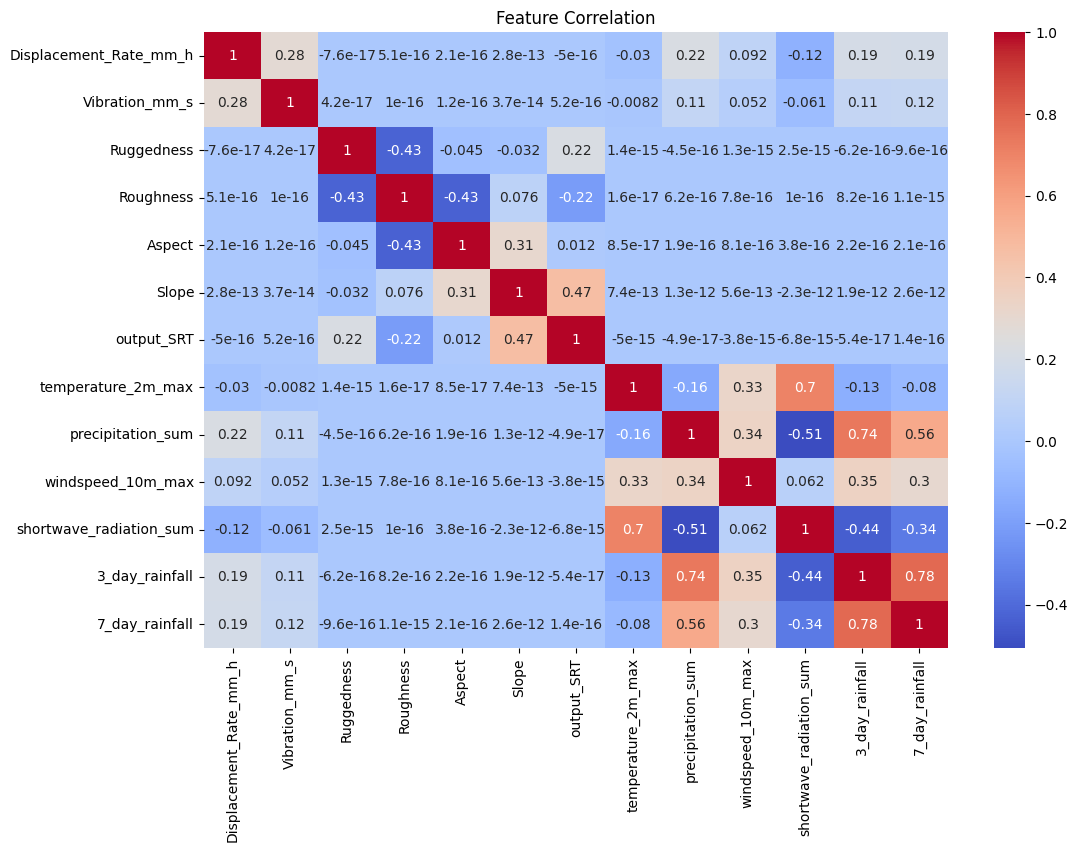


===== 8️⃣ Optional: Distribution Plots =====


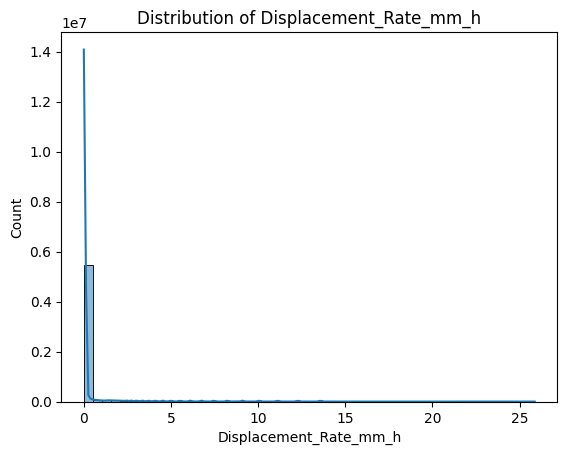

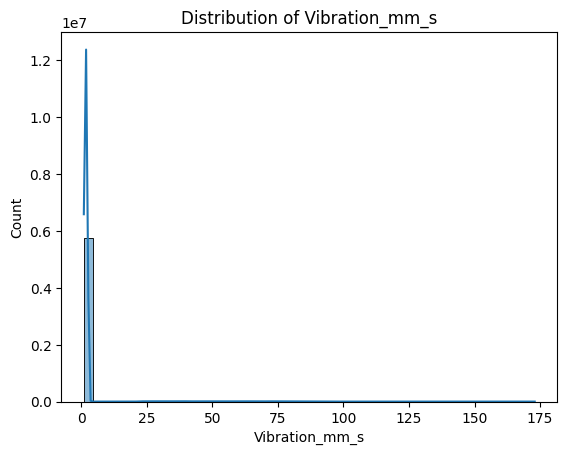

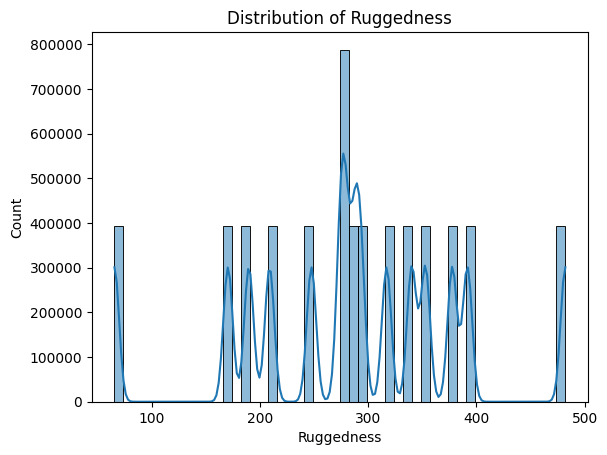

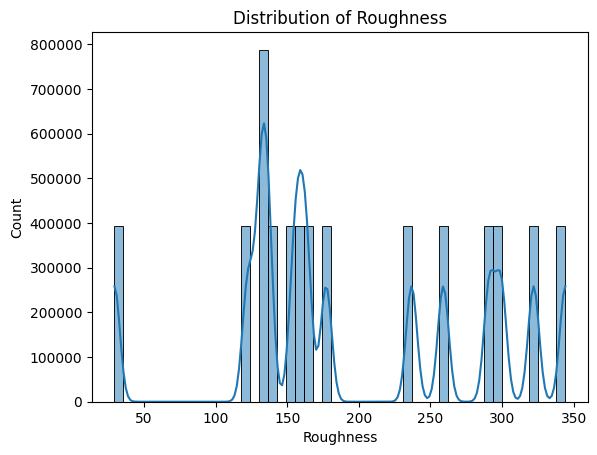

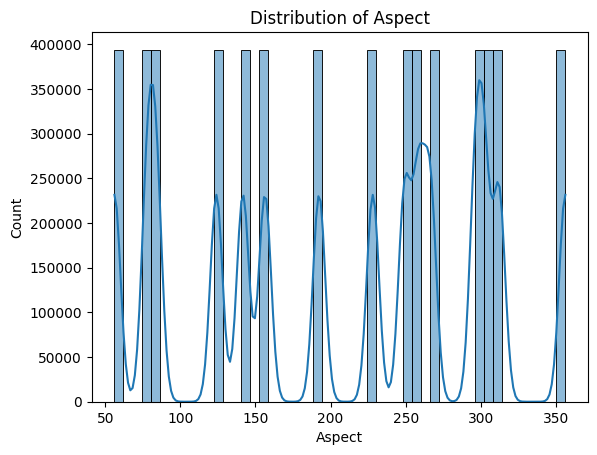

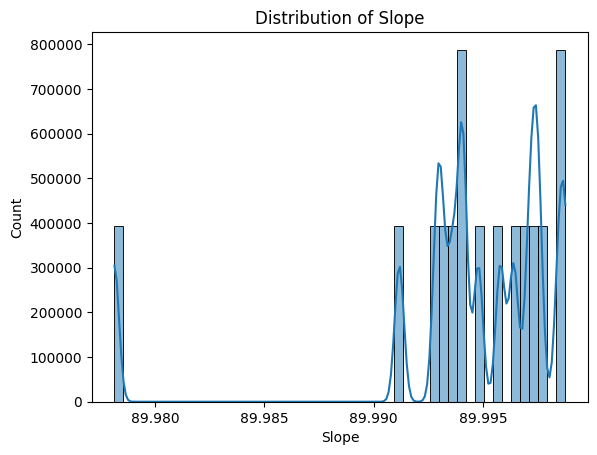

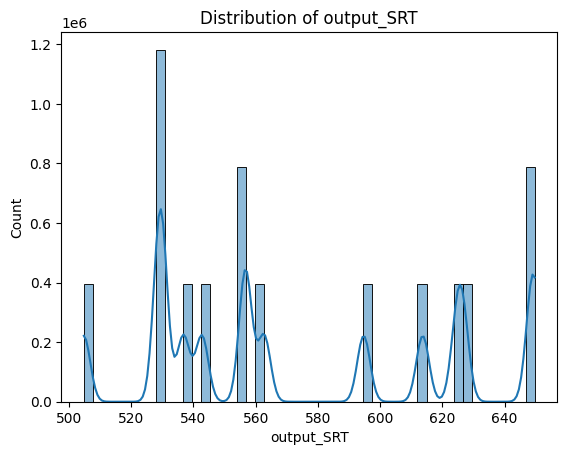

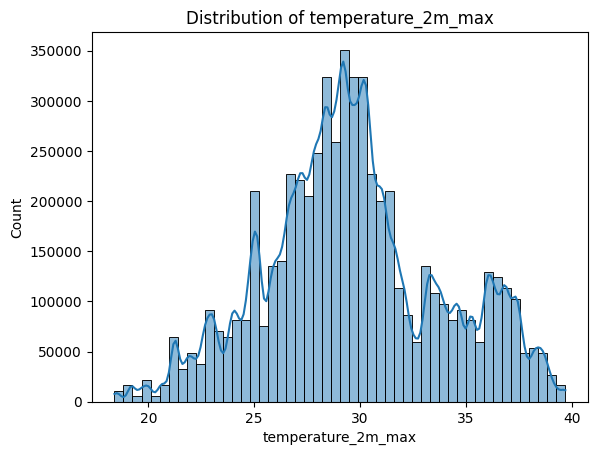

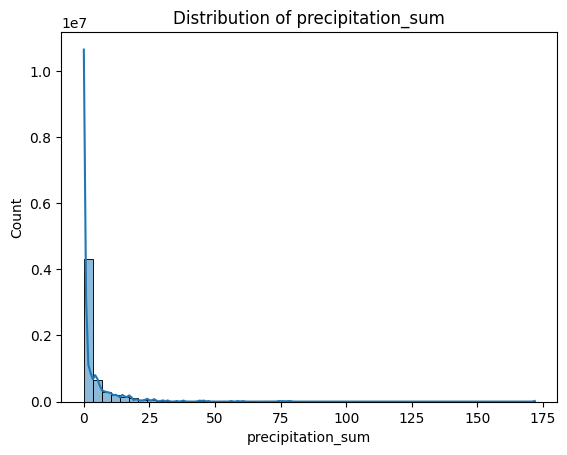

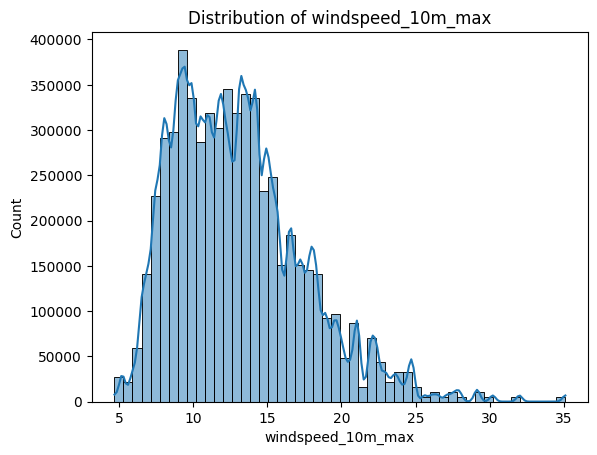


✅ Dataset validation complete.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
file_path = "data/final_master_dataset.csv"
df = pd.read_csv(file_path)

print("\n===== 1️⃣ Basic Info =====")
print(df.info())
print("\nFirst 5 rows:\n", df.head())
print("\nSummary statistics:\n", df.describe())

print("\n===== 2️⃣ Missing Values =====")
missing = df.isnull().sum()
print(missing)
if missing.sum() == 0:
    print("No missing values ✅")
else:
    print("Missing values found ⚠️")

print("\n===== 3️⃣ Duplicates =====")
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")
if dup_count == 0:
    print("No duplicates ✅")

print("\n===== 4️⃣ Column Types =====")
print(df.dtypes)

# Convert likely categorical columns
cat_cols = ['Location_ID', 'Rockfall_Event']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("\nAfter conversion:")
print(df.dtypes)

print("\n===== 5️⃣ Categorical Value Check =====")
for col in cat_cols:
    if col in df.columns:
        print(f"{col} unique values: {df[col].unique()}")

print("\n===== 6️⃣ Numeric Range Checks =====")
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
for col in numeric_cols:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}")

print("\n===== 7️⃣ Correlation Heatmap =====")
num_df = df[numeric_cols]  # select only numeric columns
plt.figure(figsize=(12, 8))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

print("\n===== 8️⃣ Optional: Distribution Plots =====")
# Plot only first 10 numeric columns to save time on large dataset
for col in numeric_cols[:10]:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f"Distribution of {col}")
    plt.show()

print("\n✅ Dataset validation complete.")

In [7]:
import pandas as pd
import numpy as np
from sklearn.utils import resample

# --------------------
# 1. Load your DEM-derived data
# --------------------
df = pd.read_csv("geometry_dataset.csv")

# Drop any unnamed index column
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# --------------------
# 2. Fix slope distribution
# --------------------
# Clip extreme slopes (remove artificial "flat = 0" or "vertical = 90 spikes")
df['Slope'] = np.clip(df['Slope'], 0, np.percentile(df['Slope'], 95))

# --------------------
# 3. Smooth Aspect and Roughness
# --------------------
# Aspect should be in [-180, 180] or [0, 360], so clip
df['Aspect'] = np.mod(df['Aspect'], 360)

# Remove extreme Roughness spikes (keep within 5–95 percentile)
df['Roughness'] = np.clip(df['Roughness'],
                          np.percentile(df['Roughness'], 5),
                          np.percentile(df['Roughness'], 95))

# Same for Ruggedness
df['Ruggedness'] = np.clip(df['Ruggedness'],
                           np.percentile(df['Ruggedness'], 5),
                           np.percentile(df['Ruggedness'], 95))

# --------------------
# 4. Add variability in Location_ID
# --------------------
n = len(df)
df['Location_ID'] = np.random.randint(1000, 2000, size=n)

# --------------------
# 5. Generate synthetic risk levels (1–5) for classification
# --------------------
# For now, base it on weighted combination of slope + roughness + ruggedness
risk_score = (0.4 * df['Slope'] +
              0.3 * df['Roughness'] +
              0.3 * df['Ruggedness'])

# Normalize score into 1–5 bins
df['Risk_Level'] = pd.qcut(risk_score, 5, labels=[1, 2, 3, 4, 5]).astype(int)

# --------------------
# 6. Balance the classes
# --------------------
min_size = df['Risk_Level'].value_counts().min()
balanced_df = pd.concat([
    resample(group, replace=False, n_samples=min_size, random_state=42)
    for _, group in df.groupby('Risk_Level')
])

# --------------------
# 7. Save the cleaned dataset
# --------------------
balanced_df.to_csv("data/DEM_data.csv", index=False)

print("✅ Cleaned & balanced dataset saved as cleaned_balanced_risk_data.csv")
print("Class distribution after balancing:")
print(balanced_df['Risk_Level'].value_counts())


ModuleNotFoundError: No module named 'sklearn'

In [5]:
%pip install sklearn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-